In [125]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scikit-learn
!pip install seaborn 

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [67]:
## Reading the dataset
df=pd.read_csv("height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

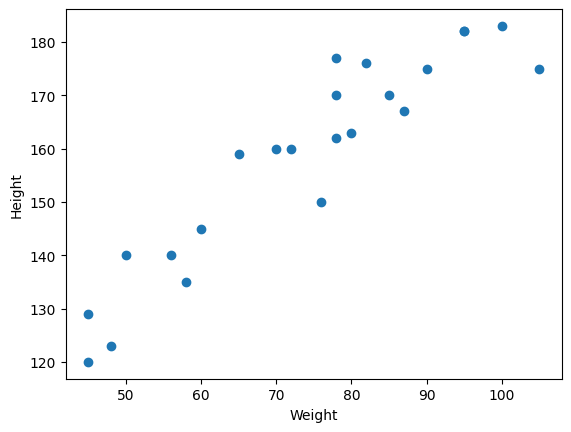

In [68]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

## **Dividing the dataset into independent and dependent features**

In [69]:

X=df[['Weight']] #independent features
y=df['Height'] #dependent features

In [70]:
X

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [71]:
y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

## **Train test split of the dataset**

In [72]:

from sklearn.model_selection import train_test_split

In [73]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [74]:
X.shape

(23, 1)

In [75]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((18, 1), (5, 1), (18,), (5,))

#### **Standardize the dataset (train independent data)**

In [76]:
from sklearn.preprocessing import StandardScaler

In [77]:
scaler=StandardScaler()

In [78]:
X_train.head()

,Weight
12,105
1,58
13,100
5,78
2,48


In [79]:
X_train=scaler.fit_transform(X_train)
X_train
X_test=scaler.transform(X_test)


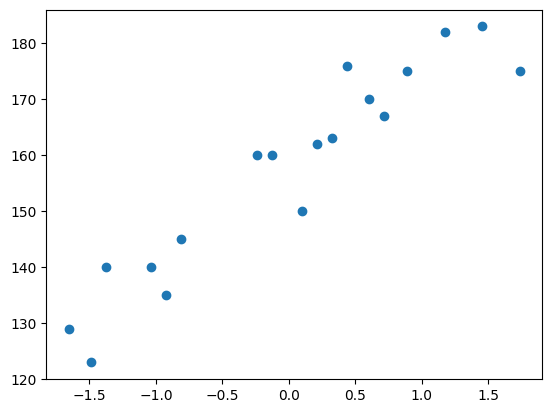

In [80]:
plt.scatter(X_train,y_train)

#### **Training the Simple Linear Regression**

In [81]:
from sklearn.linear_model import LinearRegression


In [82]:
regressor=LinearRegression()

In [83]:
regressor.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [84]:
print("The slope or coefficient of weight is ",regressor.coef_)
print("Intercept",regressor.intercept_)

The slope or coefficient of weight is  [17.03440872]
Intercept 157.5


In [89]:
X_train.shape

(18, 1)

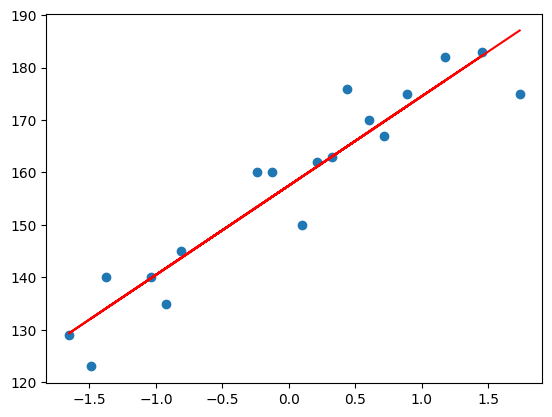

In [94]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regressor.predict(X_train),'r')

#### **Prediction of train data**

1. predicted height output=intercept+coef_(Weight)
2. y_pred_train = 157.5 + 17.03(X_train)

#### **Prediction of test data**

1. predicted height output = intercept+coef_(Weights)
2. y_pred_train = 157.5 + 17.03(X_test)

In [98]:
y_pred_test=regressor.predict(X_test)

In [99]:
y_pred_test,y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

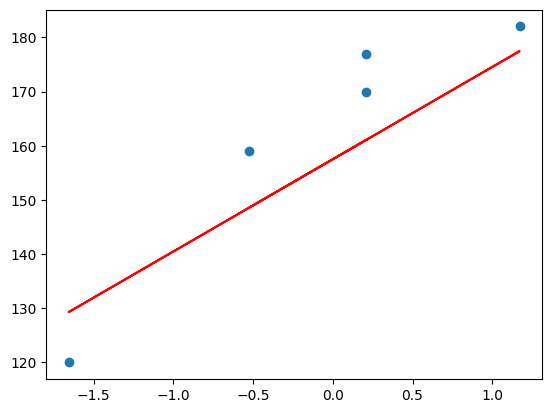

In [102]:
plt.scatter(X_test,y_test)
plt.plot(X_test,regressor.predict(X_test),'r')

#### **Performance Metrics** 

In [105]:
## MSE,MAE and RMSE
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [107]:
mse = mean_squared_error(y_test,y_pred_test) #comparing the actual and predicted values
mae = mean_absolute_error(y_test,y_pred_test)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

109.77592599051664
9.822657814519232
10.477400726827081


#### **R square**
Formuls

**R^2 = 1 - SSR/SST**

* R^2 = coefficient of determination
* SSR = sum of squares of residuals
* SST = total sum of squares


In [108]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred_test)


In [109]:
score

0.776986986042344

#### **Adjusted R Square**

**Adjusted R2 = 1 - [(1-R2)*(n-1)/(n-k-1)]**

where :
* R2: The R2 of the model
* n: the numbe of observations
* k: the number of predictor variables

In [112]:
## display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7026493147231252

In [113]:
regressor

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [114]:
## new data poiny weight is 80

scaled_weight=scaler.transform([[80]])
scaled_weight

c:\Users\impre\anaconda3\envs\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [120]:
print("The height prediction for weight 80 kg is: ",regressor.predict([scaled_weight[0]]))

The height prediction for weight 80 kg is:  [163.01076266]


## **Assumptions**


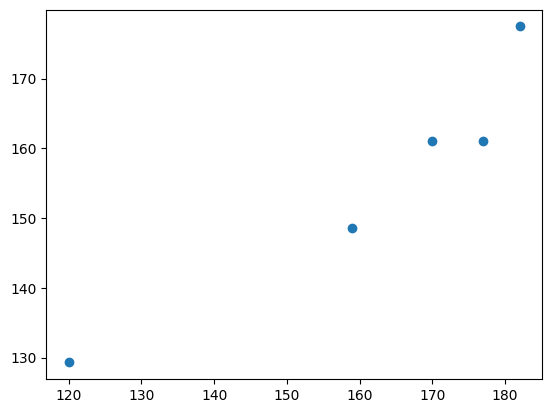

In [121]:
##Plot a scatter plot for the predictions
plt.scatter(y_test,y_pred_test)

#### **Residuals**

In [131]:
## Residuals
residuals=y_test-y_pred_test
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

In [133]:
type(residuals)


pandas.Series

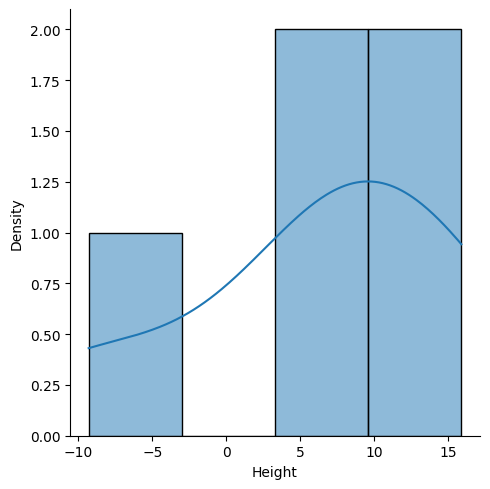

In [138]:
##Plotting the residuals
import seaborn as sns

sns.displot(residuals, kde = True)
plt.xlabel("Height")
plt.ylabel("Density")
plt.show()

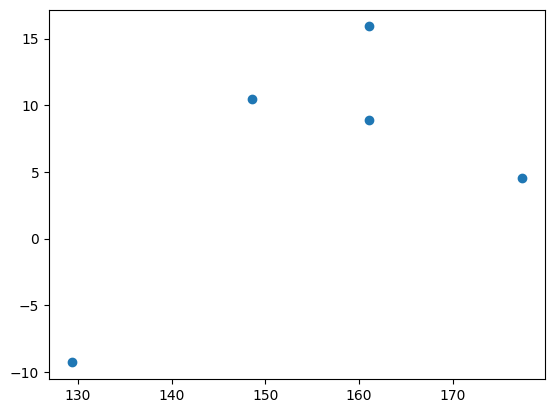

In [139]:
## Scatter plot with respect to prediction and residuals 
## uniform distribution
plt.scatter(y_pred_test,residuals)